### 1. Importing the Libraries and Loading the dataset

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("SuperStoreOrders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


-------------------------------------
### 2. Basic Structure check

In [5]:
df.shape

(51290, 21)

In [9]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

---------------------------------------------
### 3. Check for Null values

In [13]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

#### *No Null Values in the dataset*

---------------------------------------------------------
### 4. Check for Duplicate vales

In [15]:
df.duplicated().sum()

0

#### No Duplicate Values in the dataset

-----------------------------------------
### 5. Fixing Data types

In [22]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst = True, format = 'mixed')
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst = True, format = 'mixed')

In [26]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                     object
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int64
dtype: object

#### *Earlier the order_date and ship_date attribute has the object data type which is now coorected as the Datetime64.*

------------------------------------------------
### 6. Check for Outliers in sales and profit

In [36]:
df[['sales', 'profit', 'discount', 'quantity']].describe()

,profit,discount,quantity
count,51290.000000,51290.000000,51290.000000
mean,28.641740,0.142908,3.476545
std,174.424113,0.212280,2.278766
min,-6599.978000,0.000000,1.000000
25%,0.000000,0.000000,2.000000
50%,9.240000,0.000000,3.000000
75%,36.810000,0.200000,5.000000
max,8399.976000,0.850000,14.000000


-------------------------------------
### 7. Check unique values in key categorical columns

In [41]:
df['region'].unique()

array(['Africa', 'Oceania', 'EMEA', 'North', 'Canada', 'Southeast Asia',
       'Central', 'South', 'Caribbean', 'North Asia', 'East', 'West',
       'Central Asia'], dtype=object)

In [43]:
df['category'].unique()

array(['Office Supplies', 'Furniture', 'Technology'], dtype=object)

In [47]:
df['segment'].unique()

array(['Consumer', 'Home Office', 'Corporate'], dtype=object)

In [49]:
df['ship_mode'].unique()

array(['Standard Class', 'Second Class', 'Same Day', 'First Class'],
      dtype=object)

## Saving the cleaned dataset in Excel

In [52]:
df.to_csv('SuperStore_Cleaned.csv', index = False)

----------------------------------------------------------------------------------------------

# Real Business SQL queries
---------------------------------------

## Import Libraries & Load the cleaned dataset

In [271]:
import pandas as pd
import sqlite3

df1 = pd.read_csv("SuperStore_Cleaned.csv")
df1.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [71]:
print(df1.shape)

(51290, 21)


------------------------------------------
## Creating SQLite database

In [273]:
# Creating a database file called SuperStore.db
conn = sqlite3.connect("SuperStore.db")

# Loading dataframe into SQL table called "sales"
df.to_sql("sales", conn, if_exists = "replace", index = False)
print("Data loaded into SQLite Successfully!")

Data loaded into SQLite Successfully!


---------------------------------------------------
### 1. Total sales and profit by region

In [275]:
query1 = """
SELECT region,
       ROUND(SUM(sales), 2) AS total_sales,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(AVG(profit), 2) AS avg_profit
FROM sales
GROUP BY region
ORDER BY total_sales DESC;
"""

result1 = pd.read_sql(query1, conn)
result1

,region,total_sales,total_profit,avg_profit
0,Central,1806638.0,311403.98,28.01
1,South,1031101.0,140355.77,21.12
2,North,790546.0,194597.95,40.67
3,Oceania,625382.0,121666.64,34.89
4,EMEA,575562.0,43897.97,8.73
5,Africa,538115.0,88871.63,19.37
6,Southeast Asia,532172.0,17852.33,5.71
7,North Asia,453686.0,165578.42,70.82
8,West,424173.0,108418.45,33.85
9,Central Asia,389506.0,132480.19,64.69


### Business ques.1) Which region makes the most money and which is the least profitable?
### Ans.1) 
- The Central region leads in total sales 1,807,431 but needs deeper margin analysis.
- Canada shows the lowest profit 17,817 — likely due to high shipping costs and small customer base in that market.
* Recommendation: Focus growth efforts on high-margin regions and investigate why Canada underperforms despite being a developed market.

--------------------------------------------------------------------
### 2. Top 10 Products by profit

In [277]:
query2 = """
SELECT product_name,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(sales), 2) AS total_sales,
       COUNT(order_id) AS total_orders
FROM sales
GROUP BY product_name
ORDER BY total_profit DESC
LIMIT 10;
"""
result2 = pd.read_sql(query2, conn)
result2

,product_name,total_profit,total_sales,total_orders
0,Canon imageCLASS 2200 Advanced Copier,25199.93,NaN,5
1,"Cisco Smart Phone, Full Size",17238.52,7220.0,38
2,"Motorola Smart Phone, Full Size",17027.11,9157.0,38
3,"Hoover Stove, Red",11807.97,3638.0,15
4,"Sauder Classic Bookcase, Traditional",10672.07,8242.0,29
5,"Harbour Creations Executive Leather Armchair, ...",10427.33,10658.0,39
6,"Nokia Smart Phone, Full Size",9938.20,9237.0,47
7,"Cisco Smart Phone, with Caller ID",9786.64,7325.0,27
8,"Nokia Smart Phone, with Caller ID",9465.33,2301.0,24
9,"Belkin Router, USB",8955.02,10264.0,32


### Business ques.2) Which products makes the most profit?
### Ans.2)
- Canon imageCLASS 2200 Advanced Copier is the star product with $25,199 profit.
- All top 10 profitable products are from Technology and Office Supplies categories.

---------------------------------------------------------
### 3. Bottom 10 products by profit(loss makers)

In [279]:
query3 = """
SELECT product_name,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(sales), 2) AS total_sales
FROM sales
GROUP BY product_name
ORDER BY total_profit ASC
LIMIT 10;
"""
result3 = pd.read_sql(query3, conn)
result3

,product_name,total_profit,total_sales
0,Cubify CubeX 3D Printer Double Head Print,-8879.97,NaN
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.97,NaN
2,"Motorola Smart Phone, Cordless",-4447.04,4222.0
3,Cubify CubeX 3D Printer Triple Head Print,-3839.99,NaN
4,"Bevis Round Table, Adjustable Height",-3649.89,312.0
5,"Bevis Computer Table, Fully Assembled",-3509.56,6919.0
6,"Rogers Lockers, Blue",-2893.49,16494.0
7,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.12,331.0
8,"Bevis Wood Table, with Bottom Storage",-2782.59,3770.0
9,"Lesro Training Table, Rectangular",-2581.28,2712.0


### Business ques.3) Which products are actually losing the company's money?
### Ans.3)
Top 10 loss-making products lost the company significant profit despite generating sales.
- Rogers Lockers Blue is most alarming — 16,503 in sales but still $2,893 in losses, meaning every sale actually costs the business money.
- Cubify CubeX 3D Printer lost 8,879 on just 9 in sales — a critical failure.

Recommendation: Discontinue or reprice these products immediately. Review discount and shipping cost structure for Furniture and Technology items.

---------------------------------------------------------------------------------
### 4. Sales by profit by category and sub-category

In [281]:
query4 = """
SELECT category,
       sub_category,
       ROUND(SUM(sales), 2) AS total_sales,
       ROUND(SUM(profit), 2) AS total_profit,
       ROUND(SUM(profit)/SUM(sales)*100, 2) AS profit_margin_pct
FROM sales
GROUP BY category, sub_category
ORDER BY profit_margin_pct DESC;
"""
result4 = pd.read_sql(query4, conn)
result4

,category,sub_category,total_sales,total_profit,profit_margin_pct
0,Office Supplies,Appliances,377590.0,141680.59,37.52
1,Technology,Copiers,782710.0,258567.55,33.03
2,Technology,Phones,870518.0,216717.01,24.90
3,Office Supplies,Paper,244307.0,59207.68,24.23
4,Technology,Accessories,570054.0,129626.31,22.74
5,Office Supplies,Binders,346130.0,72449.85,20.93
6,Office Supplies,Labels,73433.0,15010.51,20.44
7,Furniture,Bookcases,811505.0,161924.42,19.95
8,Office Supplies,Envelopes,170926.0,29601.12,17.32
9,Office Supplies,Art,371050.0,57953.91,15.62


### Business ques.4) Which category/sub-category has the best profit margin?
### Ans.4) 
Office Supplies - Appliances has the highest profit margin at 37.47% — meaning for every 100 sold, $37.47 is pure profit.
- This makes it the most efficient category in the business.

Recommendation: Prioritize Appliances in promotions and upselling strategies since they generate the highest return per sale.

-------------------------------------------------------
### 5. Impact of discount on profit

In [284]:
query5 = """
SELECT CASE
       WHEN discount = 0 THEN 'No Discount'
       WHEN discount <= 0.2 THEN 'Low (0-0.2%)'
       WHEN discount <= 0.4 THEN 'Medium (20-40%)'
       ELSE 'High (40%+)'

       END AS discount_range,
       COUNT(*) AS total_orders,
       ROUND(AVG(profit), 2) AS avg_profit,
       ROUND(SUM(profit), 2) AS total_profit
FROM sales
GROUP BY discount_range
ORDER BY avg_profit DESC;
"""
result5 = pd.read_sql(query5, conn)
result5

,discount_range,total_orders,avg_profit,total_profit
0,No Discount,29009,61.04,1770695.27
1,Low (0-0.2%),10953,46.84,513021.63
2,Medium (20-40%),4367,-42.88,-187271.06
3,High (40%+),6961,-90.13,-627411.02


### Business ques.5) Does heavy discounting hurt profit?
### Ans.5) 
- No/Low discount (0-20%) → orders are profitable
- Medium discount (20-40%) → average profit drops to -$42.88 (loss per order)
- High discount (40%+) → average profit of -90.13, total loss of 627,411

The company is LOSING $627,411 purely because of heavy discounting.

 Recommendation: Cap maximum discount at 20% across all products. This single change could recover over 600,000 in lost profit.

------------------------------------
### 6. Yearly Sales trend

In [288]:
query6 = """
SELECT
     strftime('%Y', order_date) AS year,
     ROUND(SUM(sales), 2) AS total_sales,
     ROUND(SUM(profit), 2) AS total_profit,
     COUNT(DISTINCT order_id) AS total_orders
FROM sales
GROUP BY year
ORDER BY year ASC;
"""
result6 = pd.read_sql(query6, conn)
result6

,year,total_sales,total_profit,total_orders
0,2011,1378151.0,248940.81,4440
1,2012,1681499.0,307415.28,5343
2,2013,2107021.0,408512.76,6721
3,2014,2668457.0,504165.97,8531


### Business ques.6) Is the business growing year over year? 
### Ans.6)
The business shows consistent growth from 2011 to 2014 in both sales and orders. This confirms the company is scaling successfully.
- However, growth in sales does not always mean growth in profit — as seen in Insight 5, heavy discounting is offsetting revenue gains.

Recommendation: Maintain sales growth momentum but fix discount policy to ensure profit grows proportionally with sales.

----------------------------------------------------
## Close the database connection

In [291]:
conn.close()
print("Connection closed.")

Connection closed.


______________________________________________________________

# Exploratory Data Analysis Visualizations
-------------------------------------------------------------------------------------

## Importing libraries and loading cleaned dataset

In [127]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcdefaults()
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# Loading data
df3 = pd.read_csv("SuperStore_Cleaned.csv")
df3['sales'] = pd.to_numeric(df3['sales'], errors='coerce')
df3['profit'] = pd.to_numeric(df3['profit'], errors='coerce')
df3['discount'] = pd.to_numeric(df3['discount'], errors='coerce')
df3['quantity'] = pd.to_numeric(df3['quantity'], errors='coerce')
df3['shipping_cost'] = pd.to_numeric(df3['shipping_cost'], errors='coerce')
df3['order_date'] = pd.to_datetime(df3['order_date'], dayfirst=True, format='mixed')
df3['ship_date'] = pd.to_datetime(df3['ship_date'], dayfirst=True, format='mixed')

print("Data loaded:", df3.shape)
df3.head()

Data loaded: (51290, 21)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011


---------------------------------------------------------------------
### Visualization 1:- Sales by Region

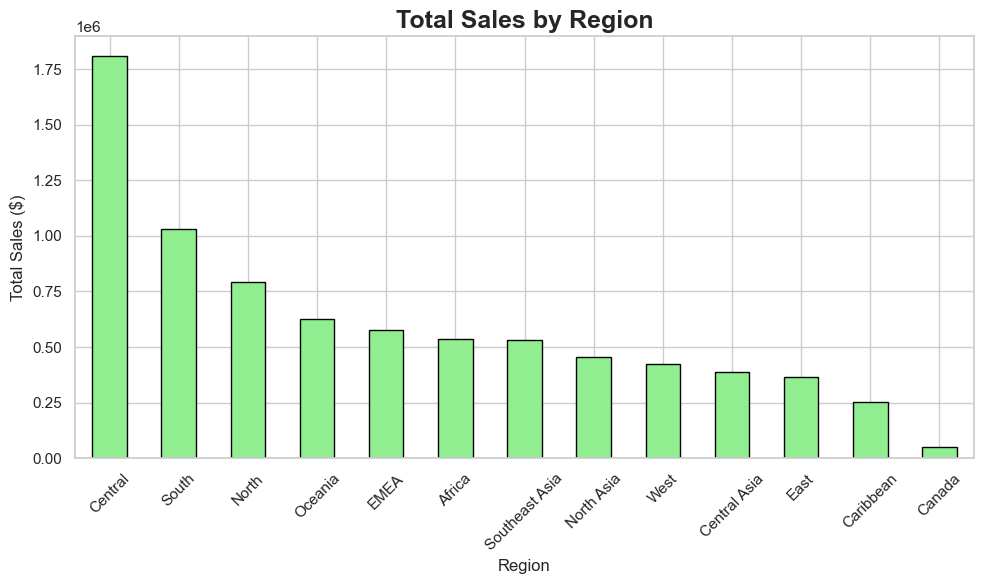

In [171]:
region_sales = df3.groupby('region')['sales'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Total Sales by Region', fontsize=18, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('1_sales_by_region.png')
plt.show()

#### INSIGHT: Central region leads in total sales at ($1.8M)
- High sales don't always mean high profit — compare with 2nd Visualization
---------------------------------------------------------------------------------------------------

### Visualization 2:- Profit by Region

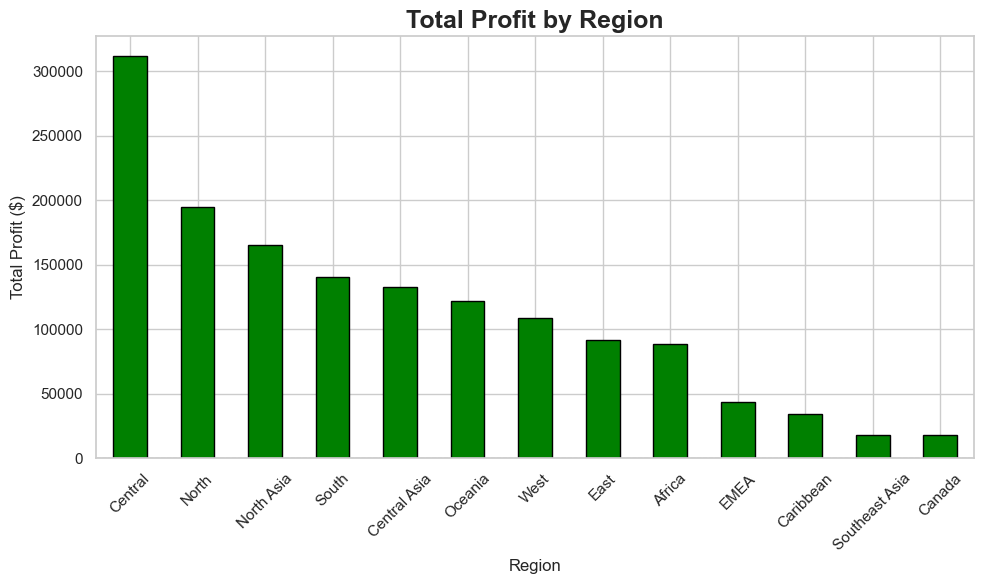

In [167]:
region_profit = df3.groupby('region')['profit'].sum().sort_values(ascending=False)

colors = ['green' if x > 0 else 'red' for x in region_profit]
region_profit.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Total Profit by Region', fontsize=18, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('2_profit_by_region.png')
plt.show()

#### INSIGHT: Canada is least profitable despite being a separate market
----------------------------------------------------------------------------------------------

### Visualization 3:- Yearly Sales Trend

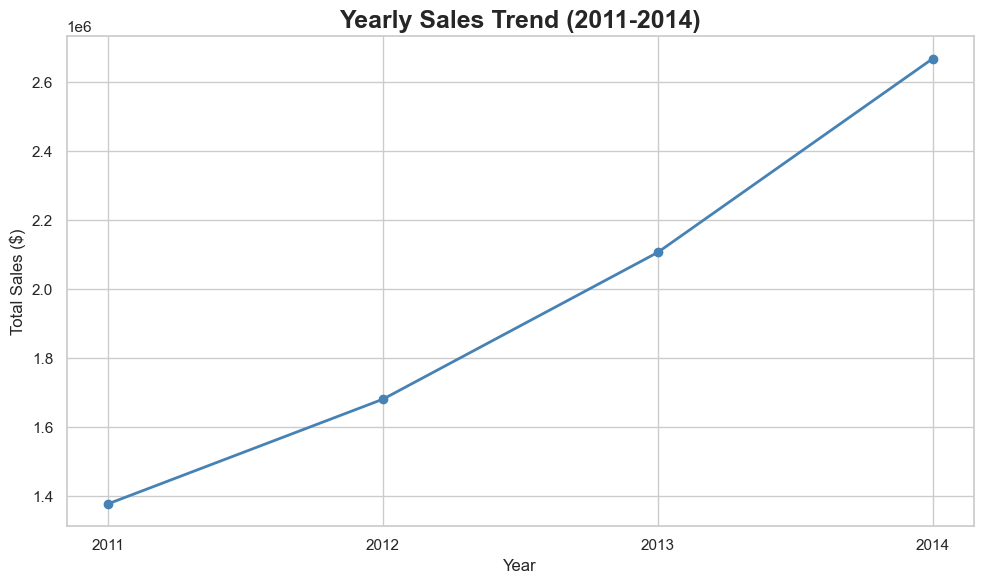

In [165]:
df3['year'] = df3['order_date'].dt.year
yearly_sales = df3.groupby('year')['sales'].sum()

yearly_sales.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Yearly Sales Trend (2011-2014)', fontsize=18, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.xticks([2011, 2012, 2013, 2014])
plt.tight_layout()
plt.savefig('chart3_yearly_trend.png')
plt.show()

#### INSIGHT: Consistent year-over-year growth from 2011 to 2014
- Business is expanding — revenue growing each year
- -----------------------------------------------------------------------------------------

### Visualization 4:- Sales VS Profit by Category

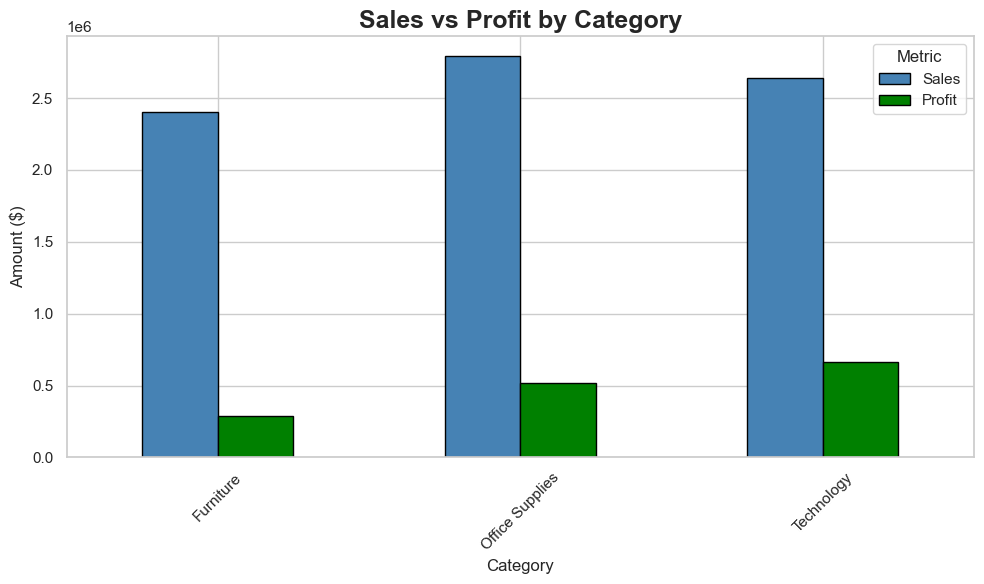

In [163]:
category_sales = df3.groupby('category')['sales'].sum()
category_profit = df3.groupby('category')['profit'].sum()

category_df3 = pd.DataFrame({'Sales': category_sales, 'Profit': category_profit})
category_df3.plot(kind='bar', color=['steelblue', 'green'], edgecolor='black')

plt.title('Sales vs Profit by Category', fontsize=18, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('chart4_category.png')
plt.show()

#### INSIGHT: Office Supplies has highest sales but Technology has best profit margin
- Furniture has high sales but lowest profit — likely due to heavy discounting
- ----------------------------------------------------------------------------------------------

### Visualization 5:- Discount VS Profit

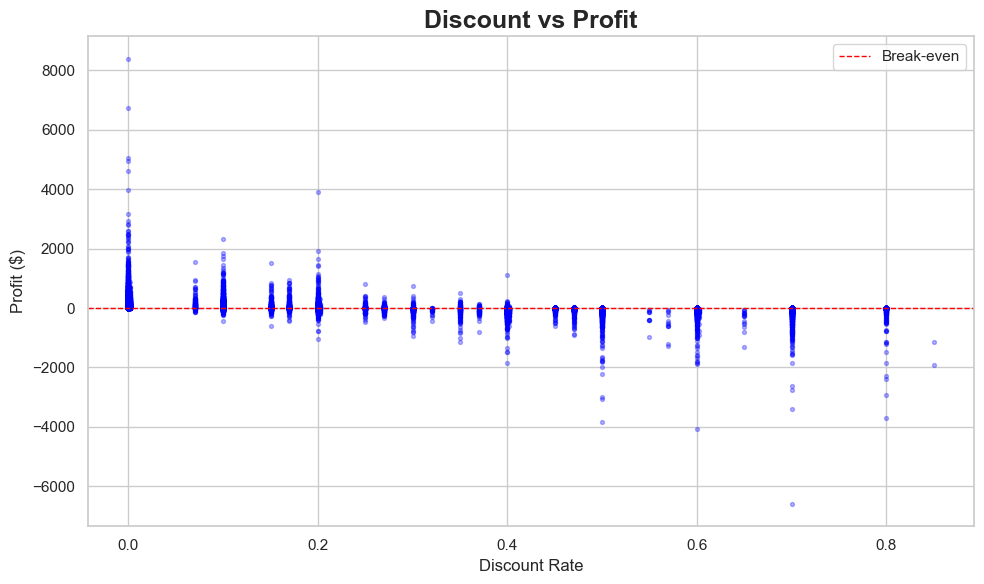

In [188]:
plt.scatter(df3['discount'], df3['profit'], alpha=0.3, color='blue', s=8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Break-even')
plt.title('Discount vs Profit', fontsize=18, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('5_discount_profit.png')
plt.show()

#### INSIGHT: Clear pattern — profit drops below zero when discount exceeds 20%.
- Visually proves our SQL finding: high discounts cause $627K+ in losses
---------------------------------------

### Visualization 6:- Top 10 Profitable Products

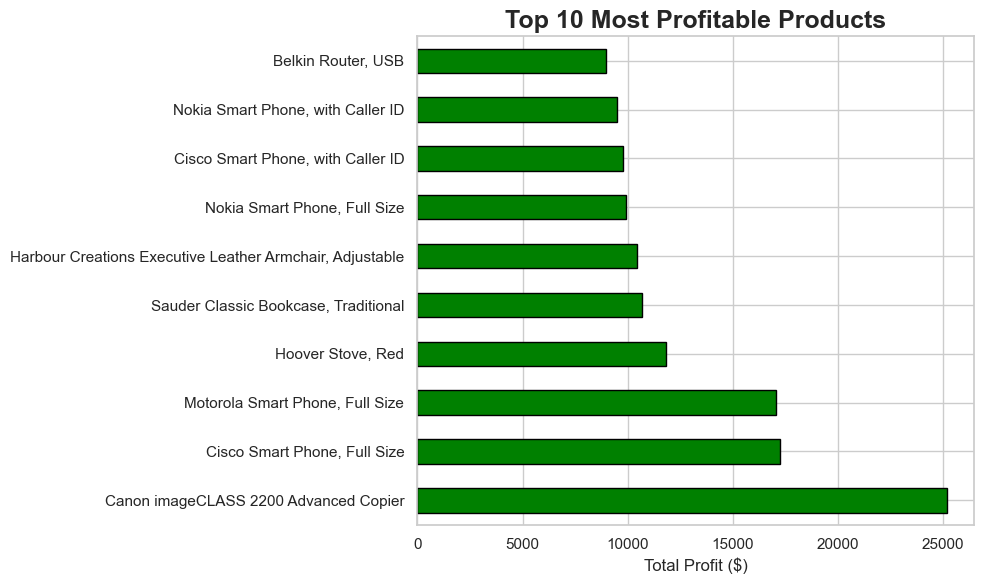

In [195]:
top10 = df3.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)

top10.plot(kind='barh', color='green', edgecolor='black')
plt.title('Top 10 Most Profitable Products', fontsize=18, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('6_top10_products.png')
plt.show()

#### INSIGHT: Canon imageCLASS 2200 Copier is the top profit driver at $25,199
- Technology products dominate top 10 — strong candidate for increased marketing
- -------------------------------------------------------------------------------------

### Visualization 7:- Correlation Heatmap

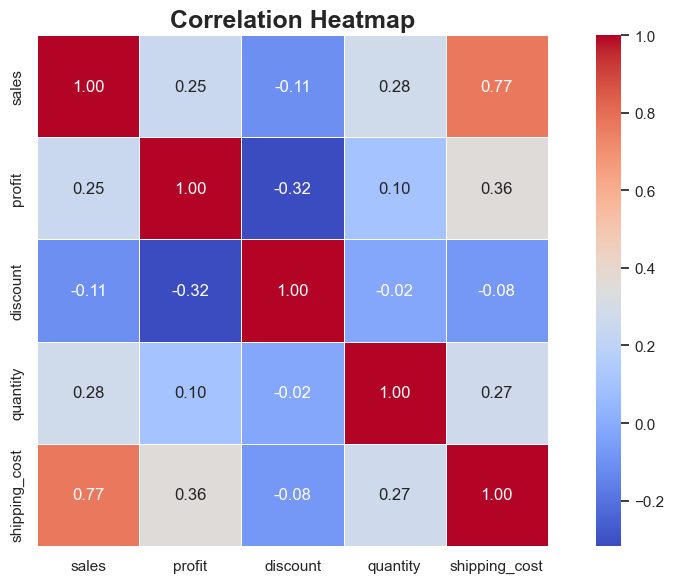

In [208]:
numeric_cols = df3[['sales', 'profit', 'discount', 'quantity', 'shipping_cost']]
correlation = numeric_cols.corr()

sns.heatmap(correlation, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square= True)
plt.title('Correlation Heatmap', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('7_heatmap.png')
plt.show()

#### INSIGHT: Discount and profit show strong negative correlation
- Confirms: more discount = less profit every single time

---------------------------------------------------------
## FINAL SUMMARY — KEY BUSINESS INSIGHTS
---------------------------------------------------------
### 1. REGIONAL PERFORMANCE
- Central region leads in sales ($1.8M) but profit analysis reveals Canada is the weakest market — needs strategic review

### 2. PRODUCT PERFORMANCE
- Canon imageCLASS 2200 Copier = star product (25,199 profit)
- Cubify CubeX 3D Printer = worst product (-8,879 loss on just $9 sales)
* Action: Discontinue loss-makers, double down on top performers

### 3. DISCOUNT PROBLEM (BIGGEST FINDING)
- Discounts above 20% push profit below zero — every single time
- High discounts (40%+) caused $627,411 in total losses
* Action: Cap all discounts at 20% company-wide immediately

### 4. CATEGORY INSIGHTS
- Office Supplies → Appliances = best profit margin (37.47%)
- Furniture = high sales but lowest profit — over-discounted
* Action: Prioritize Appliances in marketing, audit Furniture pricing

### 5. BUSINESS GROWTH
- Consistent YoY growth 2011-2014 — business is healthy and expanding but growing revenue is being eaten by discount losses
* Action: Fix discount policy to convert revenue growth into profit growth

#### This business is growing but leaving $600K+ on the table every year through poor discount management. Fixing discounts alone would dramatically improve profitability without needing more sales.

-------------------------------------------------------